In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("Libraries loaded successfully!")

Libraries loaded successfully!


Dataset loaded successfully! Total rows: 5000
Label Mapping: {'High Risk': 0, 'Medium Risk': 1, 'No Risk': 2}

--- Data Distribution ---
Risk_Level
Medium Risk    1734
No Risk        1684
High Risk      1582
Name: count, dtype: int64


C:\Users\Chamodi Hansani\AppData\Local\Temp\ipykernel_2404\2785283546.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Risk_Level', palette='viridis')


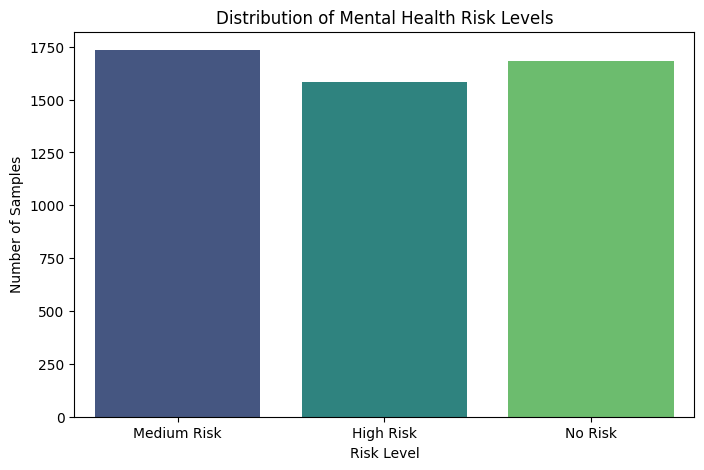

In [8]:
# --- FULL CELL 2 ---
import os

# 1. Define the path
file_path = os.path.join('data', 'Mental_Health_Risks_Dataset.xlsx')

# 2. Load the data
if os.path.exists(file_path):
    df = pd.read_excel(file_path)
    print(f"Dataset loaded successfully! Total rows: {len(df)}")
    
    # 3. Clean the text
    def clean_text(text):
        text = str(text).lower()
        # This handles Sinhala unicode normalization
        text = "".join(c for c in text if not unicodedata.combining(c)) 
        text = re.sub(r"http\S+|www\S+|https\S+", "", text)
        return text.strip()

    df['clean_text'] = df['Text'].apply(clean_text)

    # 4. Encode Labels (High Risk, etc. into numbers)
    le = LabelEncoder()
    df['label'] = le.fit_transform(df['Risk_Level'])
    
    print("Label Mapping:", dict(zip(le.classes_, range(len(le.classes_)))))
else:
    print(f"ERROR: I looked in the 'data' folder but couldn't find the file.")
    print(f"Current Folder: {os.getcwd()}")

# Check the counts of each category
risk_counts = df['Risk_Level'].value_counts()
print("\n--- Data Distribution ---")
print(risk_counts)

# Visualize it
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Risk_Level', palette='viridis')
plt.title('Distribution of Mental Health Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Number of Samples')
plt.show()

In [11]:
# 1. Split Data (80% Training, 20% Testing)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# --- ADD THIS PART TO SHOW THE COUNTS ---
print("--- Data Split Summary ---")
print(f"Total rows in dataset: {len(df)}")
print(f"Training samples (80%): {len(X_train_raw)}")
print(f"Testing samples  (20%): {len(X_test_raw)}")
print("--------------------------")

# 2. Convert to TF-IDF
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

print(f"Data vectorized. Features (unique words/phrases): {X_train.shape[1]}")

--- Data Split Summary ---
Total rows in dataset: 5000
Training samples (80%): 4000
Testing samples  (20%): 1000
--------------------------
Data vectorized. Features (unique words/phrases): 5000


In [15]:
# 1. Define the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM (Linear)": SVC(kernel='linear'),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier()
}

results = []

# 2. Loop through each model
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # Calculate global metrics
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    
    results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})
    
    # --- PRINT DETAILED PRECISION & RECALL ---
    print(f"\n" + "="*50)
    print(f"DETAILED REPORT FOR: {name}")
    print("="*50)
    # Using target_names allows you to see the actual Risk Labels
    print(classification_report(y_test, preds, target_names=le.classes_))

# 3. Final Comparison Table
comparison_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n" + "*"*30)
print("FINAL BASELINE ACCURACY COMPARISON")
print("*"*30)
print(comparison_df)


DETAILED REPORT FOR: Logistic Regression
              precision    recall  f1-score   support

   High Risk       0.68      0.68      0.68       316
 Medium Risk       0.59      0.65      0.62       347
     No Risk       0.77      0.68      0.72       337

    accuracy                           0.67      1000
   macro avg       0.68      0.67      0.67      1000
weighted avg       0.68      0.67      0.67      1000


DETAILED REPORT FOR: Naive Bayes
              precision    recall  f1-score   support

   High Risk       0.67      0.69      0.68       316
 Medium Risk       0.55      0.69      0.61       347
     No Risk       0.83      0.57      0.68       337

    accuracy                           0.65      1000
   macro avg       0.68      0.65      0.66      1000
weighted avg       0.68      0.65      0.66      1000


DETAILED REPORT FOR: SVM (Linear)
              precision    recall  f1-score   support

   High Risk       0.71      0.69      0.70       316
 Medium Risk      

C:\Users\Chamodi Hansani\AppData\Local\Temp\ipykernel_2404\2088572905.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Accuracy', y='Model', data=comparison_df, palette='viridis')


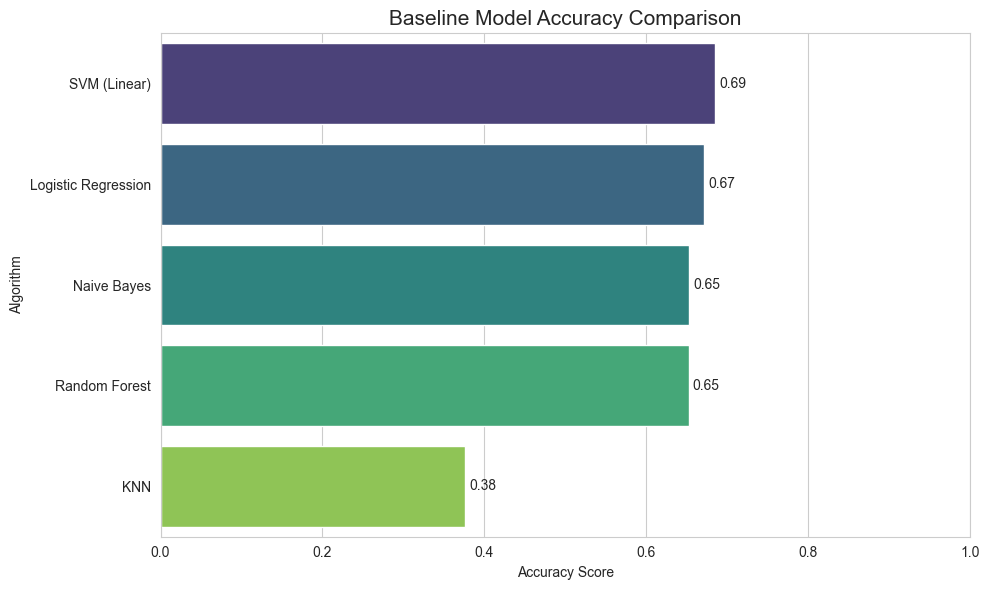

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create the bar plot
ax = sns.barplot(x='Accuracy', y='Model', data=comparison_df, palette='viridis')

# Add labels to the bars
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f', padding=3)

plt.title('Baseline Model Accuracy Comparison', fontsize=15)
plt.xlim(0, 1.0) # Accuracy is between 0 and 1
plt.xlabel('Accuracy Score')
plt.ylabel('Algorithm')
plt.tight_layout()
plt.show()